In [1]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/sathvik2006/annotations/train_annotations.csv")
val_df = pd.read_csv("/kaggle/input/datasets/sathvik2006/annotations/val_annotations.csv")
test_df = pd.read_csv("/kaggle/input/datasets/sathvik2006/annotations/test_annotations.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_df.head()

Train: 39241
Val: 8386
Test: 8453


,image,category,bbox,segmentation
0,161364.jpg,trousers,"[252, 323, 522, 639]","[[432, 324, 339, 353, 250, 393, 290, 532, 346,..."
1,161364.jpg,short sleeve top,"[30, 1, 466, 481]","[[183, 5, 175, 19, 157, 35, 125, 48, 92, 51, 8..."
2,117178.jpg,trousers,"[159, 423, 337, 701]","[[328, 432, 249, 432, 162, 430, 164, 540, 164,..."
3,131919.jpg,trousers,"[158, 381, 366, 650]","[[346, 450, 263, 438, 227, 388, 203, 451, 186,..."
4,131919.jpg,short sleeve top,"[212, 140, 481, 492]","[[429, 214, 407, 230, 378, 229, 354, 210, 353,..."


In [2]:
import pandas as pd



# group labels per image
train_group = train_df.groupby("image")["category"].apply(list).reset_index()
val_group = val_df.groupby("image")["category"].apply(list).reset_index()
test_group = test_df.groupby("image")["category"].apply(list).reset_index()

train_group.head()

,image,category
0,000014.jpg,"[skirt, long sleeve top]"
1,000015.jpg,[long sleeve top]
2,000018.jpg,"[trousers, long sleeve top]"
3,000026.jpg,"[skirt, short sleeve top]"
4,000027.jpg,"[skirt, short sleeve top]"


In [3]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

train_labels = mlb.fit_transform(train_group["category"])
val_labels = mlb.transform(val_group["category"])
test_labels = mlb.transform(test_group["category"])

print(mlb.classes_)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']


In [4]:
import torch 
labels_matrix = train_labels   # shape [N, C]

pos_counts = labels_matrix.sum(axis=0)
neg_counts = labels_matrix.shape[0] - pos_counts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.tensor(
    neg_counts / (pos_counts + 1e-6),
    dtype=torch.float
).to(device)
print(mlb.classes_)
print("Correct pos_weight:", pos_weight)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']
Correct pos_weight: tensor([3.0496, 1.0334, 2.9657, 3.6053, 1.6412], device='cuda:0')


In [5]:
from torchvision import transforms

# ImageNet normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Added Gaussian Blur
    transforms.ToTensor(),
    normalize
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class FashionDataset(Dataset):

    def __init__(self, df, labels, img_dir, transform=None):
        self.df = df
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_name = self.df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx]).float()

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
img_dir = "/kaggle/input/datasets/sathvik2006/sample35t/sample_35k/images"

train_dataset = FashionDataset(train_group, train_labels, img_dir, train_tf)
val_dataset = FashionDataset(val_group, val_labels, img_dir, val_tf)
test_dataset = FashionDataset(test_group, test_labels, img_dir, val_tf)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 24500
Val: 5250
Test: 5250


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 5])


# Resnet50

In [9]:
import torchvision.models as models
import torch.nn as nn
import torch
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_classes = len(mlb.classes_)
# Freeze partially, not fully
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last layers
for param in model.layer4.parameters():   # for ResNet
    param.requires_grad = True

# replace final layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


In [10]:
import torch.optim as optim
from torch.optim import lr_scheduler

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Consistent optimizer scope: include all parameters (even if frozen, they won't update)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
# Added LR Scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [11]:
num_epochs =30
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    # Validation Loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
    
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_mobilenet.pth')
        print("✔ Best model saved")

Epoch [1/30] | Train Loss: 0.7272 | Val Loss: 0.5644
✔ Best model saved
Epoch [2/30] | Train Loss: 0.5469 | Val Loss: 0.4955
✔ Best model saved
Epoch [3/30] | Train Loss: 0.4681 | Val Loss: 0.4715
✔ Best model saved
Epoch [4/30] | Train Loss: 0.4089 | Val Loss: 0.4594
✔ Best model saved
Epoch [5/30] | Train Loss: 0.3472 | Val Loss: 0.4597
Epoch [6/30] | Train Loss: 0.2999 | Val Loss: 0.4736
Epoch [7/30] | Train Loss: 0.2529 | Val Loss: 0.4937
Epoch [8/30] | Train Loss: 0.2110 | Val Loss: 0.4970
Epoch [9/30] | Train Loss: 0.2018 | Val Loss: 0.5079
Epoch [10/30] | Train Loss: 0.1964 | Val Loss: 0.5074
Epoch [11/30] | Train Loss: 0.1935 | Val Loss: 0.5038
Epoch [12/30] | Train Loss: 0.1910 | Val Loss: 0.5081
Epoch [13/30] | Train Loss: 0.1902 | Val Loss: 0.5096
Epoch [14/30] | Train Loss: 0.1917 | Val Loss: 0.5141
Epoch [15/30] | Train Loss: 0.1902 | Val Loss: 0.5050
Epoch [16/30] | Train Loss: 0.1909 | Val Loss: 0.5153
Epoch [17/30] | Train Loss: 0.1917 | Val Loss: 0.5114
Epoch [18/30] |

In [12]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
model.load_state_dict(torch.load('best_mobilenet.pth'))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
thresholds = []

for i in range(all_probs.shape[1]):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds,zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

# Apply thresholds
all_preds = np.zeros_like(all_probs)
for i in range(len(thresholds)):
    all_preds[:, i] = (all_probs[:, i] > thresholds[i]).astype(int)

In [13]:
print(classification_report(all_labels, all_preds, target_names=mlb.classes_))

                  precision    recall  f1-score   support

 long sleeve top       0.68      0.67      0.67      1312
short sleeve top       0.72      0.86      0.78      2566
          shorts       0.82      0.81      0.81      1329
           skirt       0.70      0.76      0.73      1104
        trousers       0.93      0.88      0.90      1992

       micro avg       0.77      0.81      0.79      8303
       macro avg       0.77      0.80      0.78      8303
    weighted avg       0.78      0.81      0.79      8303
     samples avg       0.77      0.82      0.77      8303



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
macro_f1 = f1_score(all_labels, all_preds, average='macro')
micro_f1 = f1_score(all_labels, all_preds, average='micro')
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Macro F1: 0.780529761865376
Micro F1: 0.7910980966325036


In [15]:
from sklearn.metrics import roc_auc_score
# Using probabilities for AUC
roc_auc = roc_auc_score(all_labels, all_probs, average=None)

for i, cls in enumerate(mlb.classes_):
    print(f"{cls} AUC: {roc_auc[i]:.4f}")

long sleeve top AUC: 0.8829
short sleeve top AUC: 0.8633
shorts AUC: 0.9537
skirt AUC: 0.9308
trousers AUC: 0.9760


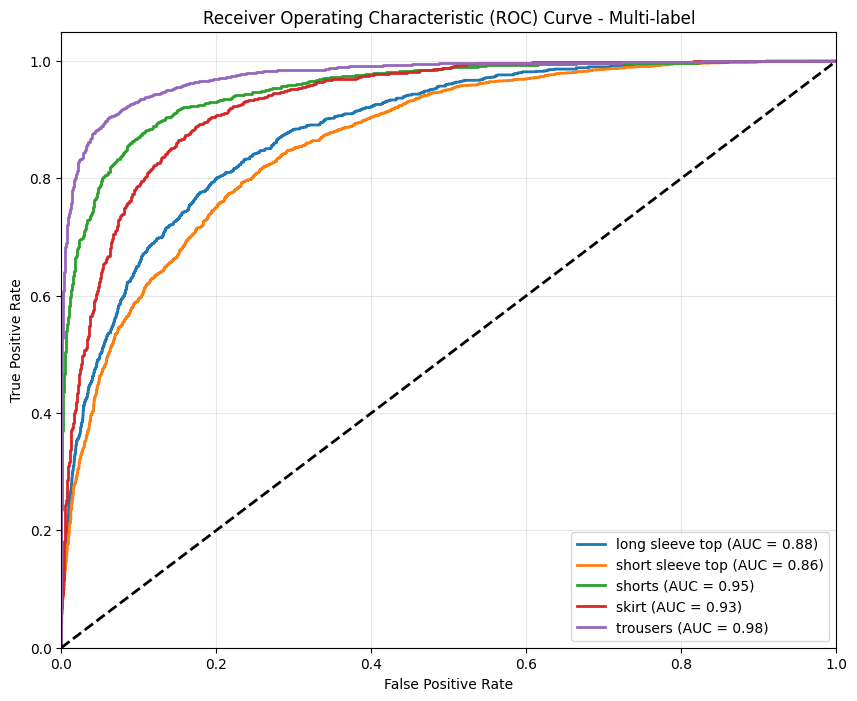

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multilabel_roc(all_labels, all_probs, class_names):
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-label')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Generate the plot using labels and probabilities from the latest model evaluation
plot_multilabel_roc(all_labels, all_probs, mlb.classes_)

# MobileNetV3 

In [17]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [18]:
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-2:].parameters():
    param.requires_grad = True
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 150MB/s]


In [19]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [20]:
num_epochs = 30
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(model(images), labels).item()
    
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_mobilenet_v3.pth')
        print("✔ Best model saved")

Epoch [1/30] | Train Loss: 0.9308 | Val Loss: 0.8969
✔ Best model saved
Epoch [2/30] | Train Loss: 0.8682 | Val Loss: 0.8285
✔ Best model saved
Epoch [3/30] | Train Loss: 0.8025 | Val Loss: 0.7678
✔ Best model saved
Epoch [4/30] | Train Loss: 0.7563 | Val Loss: 0.7312
✔ Best model saved
Epoch [5/30] | Train Loss: 0.7258 | Val Loss: 0.7066
✔ Best model saved
Epoch [6/30] | Train Loss: 0.7028 | Val Loss: 0.6887
✔ Best model saved
Epoch [7/30] | Train Loss: 0.6864 | Val Loss: 0.6740
✔ Best model saved
Epoch [8/30] | Train Loss: 0.6736 | Val Loss: 0.6628
✔ Best model saved
Epoch [9/30] | Train Loss: 0.6614 | Val Loss: 0.6536
✔ Best model saved
Epoch [10/30] | Train Loss: 0.6484 | Val Loss: 0.6444
✔ Best model saved
Epoch [11/30] | Train Loss: 0.6398 | Val Loss: 0.6367
✔ Best model saved
Epoch [12/30] | Train Loss: 0.6319 | Val Loss: 0.6310
✔ Best model saved
Epoch [13/30] | Train Loss: 0.6232 | Val Loss: 0.6250
✔ Best model saved
Epoch [14/30] | Train Loss: 0.6133 | Val Loss: 0.6197
✔ Best

In [21]:
model.load_state_dict(torch.load('best_mobilenet_v3.pth'))
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        all_probs.append(torch.sigmoid(outputs).cpu().numpy())
        all_labels.append(labels.numpy())
all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
thresholds = []

for i in range(all_probs.shape[1]):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds,zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

# Apply thresholds
all_preds = np.zeros_like(all_probs)
for i in range(len(thresholds)):
    all_preds[:, i] = (all_probs[:, i] > thresholds[i]).astype(int)

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=mlb.classes_
))

                  precision    recall  f1-score   support

 long sleeve top       0.57      0.66      0.61      1312
short sleeve top       0.61      0.91      0.73      2566
          shorts       0.72      0.76      0.74      1329
           skirt       0.53      0.75      0.62      1104
        trousers       0.85      0.85      0.85      1992

       micro avg       0.65      0.81      0.72      8303
       macro avg       0.66      0.79      0.71      8303
    weighted avg       0.67      0.81      0.73      8303
     samples avg       0.68      0.81      0.71      8303



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(all_labels, all_preds, average="macro")
micro_f1 = f1_score(all_labels, all_preds, average="micro")

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Macro F1: 0.7107863615080736
Micro F1: 0.7241990017710513


In [24]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(all_labels, all_probs, average=None)
for i, cls in enumerate(mlb.classes_):
    print(f"{cls} AUC: {roc_auc[i]:.4f}")

long sleeve top AUC: 0.8350
short sleeve top AUC: 0.7892
shorts AUC: 0.9228
skirt AUC: 0.8729
trousers AUC: 0.9521


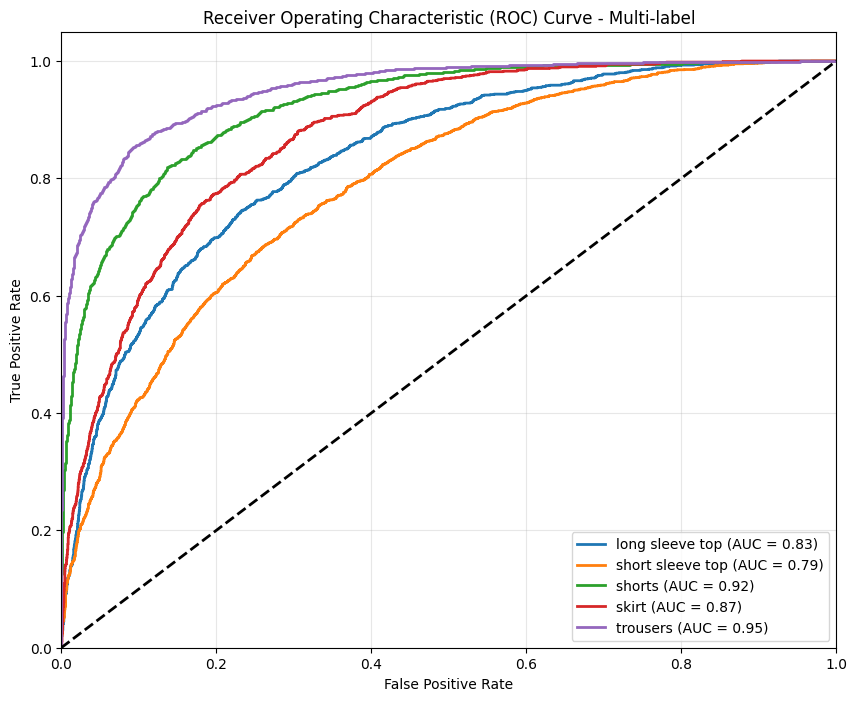

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multilabel_roc(all_labels, all_probs, class_names):
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-label')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Generate the plot using labels and probabilities from the latest model evaluation
plot_multilabel_roc(all_labels, all_probs, mlb.classes_)

# EfficientNet-B0 


In [26]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last few blocks
for param in model.features[-4:].parameters():
    param.requires_grad = True
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 


In [27]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [28]:
num_epochs = 30
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(model(images), labels).item()
    
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_effnet.pth')
        print("✔ Best model saved")

Epoch [1/30] | Train Loss: 0.5886 | Val Loss: 0.4805
✔ Best model saved
Epoch [2/30] | Train Loss: 0.4598 | Val Loss: 0.4382
✔ Best model saved
Epoch [3/30] | Train Loss: 0.3953 | Val Loss: 0.4157
✔ Best model saved
Epoch [4/30] | Train Loss: 0.3484 | Val Loss: 0.4092
✔ Best model saved
Epoch [5/30] | Train Loss: 0.3103 | Val Loss: 0.4050
✔ Best model saved
Epoch [6/30] | Train Loss: 0.2777 | Val Loss: 0.4260
Epoch [7/30] | Train Loss: 0.2478 | Val Loss: 0.4327
Epoch [8/30] | Train Loss: 0.2182 | Val Loss: 0.4825
Epoch [9/30] | Train Loss: 0.1476 | Val Loss: 0.4689
Epoch [10/30] | Train Loss: 0.1126 | Val Loss: 0.5019
Epoch [11/30] | Train Loss: 0.0953 | Val Loss: 0.5367
Epoch [12/30] | Train Loss: 0.0853 | Val Loss: 0.5277
Epoch [13/30] | Train Loss: 0.0810 | Val Loss: 0.5243
Epoch [14/30] | Train Loss: 0.0822 | Val Loss: 0.5288
Epoch [15/30] | Train Loss: 0.0790 | Val Loss: 0.5313
Epoch [16/30] | Train Loss: 0.0797 | Val Loss: 0.5373
Epoch [17/30] | Train Loss: 0.0785 | Val Loss: 0.5

In [29]:
model.load_state_dict(torch.load('best_effnet.pth'))
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        all_probs.append(torch.sigmoid(outputs).cpu().numpy())
        all_labels.append(labels.numpy())
all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
thresholds = []

for i in range(all_probs.shape[1]):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds,zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)

# Apply thresholds
all_preds = np.zeros_like(all_probs)
for i in range(len(thresholds)):
    all_preds[:, i] = (all_probs[:, i] > thresholds[i]).astype(int)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=mlb.classes_
))

                  precision    recall  f1-score   support

 long sleeve top       0.70      0.78      0.74      1312
short sleeve top       0.79      0.89      0.83      2566
          shorts       0.87      0.83      0.85      1329
           skirt       0.70      0.81      0.75      1104
        trousers       0.90      0.93      0.91      1992

       micro avg       0.80      0.86      0.83      8303
       macro avg       0.79      0.85      0.82      8303
    weighted avg       0.80      0.86      0.83      8303
     samples avg       0.81      0.86      0.82      8303



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(all_labels, all_preds, average="macro")
micro_f1 = f1_score(all_labels, all_preds, average="micro")

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Macro F1: 0.8177811905038956
Micro F1: 0.8286824853512792


In [32]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(all_labels, all_probs, average=None)
for i, cls in enumerate(mlb.classes_):
    print(f"{cls} AUC: {roc_auc[i]:.4f}")

long sleeve top AUC: 0.9238
short sleeve top AUC: 0.9168
shorts AUC: 0.9662
skirt AUC: 0.9419
trousers AUC: 0.9822


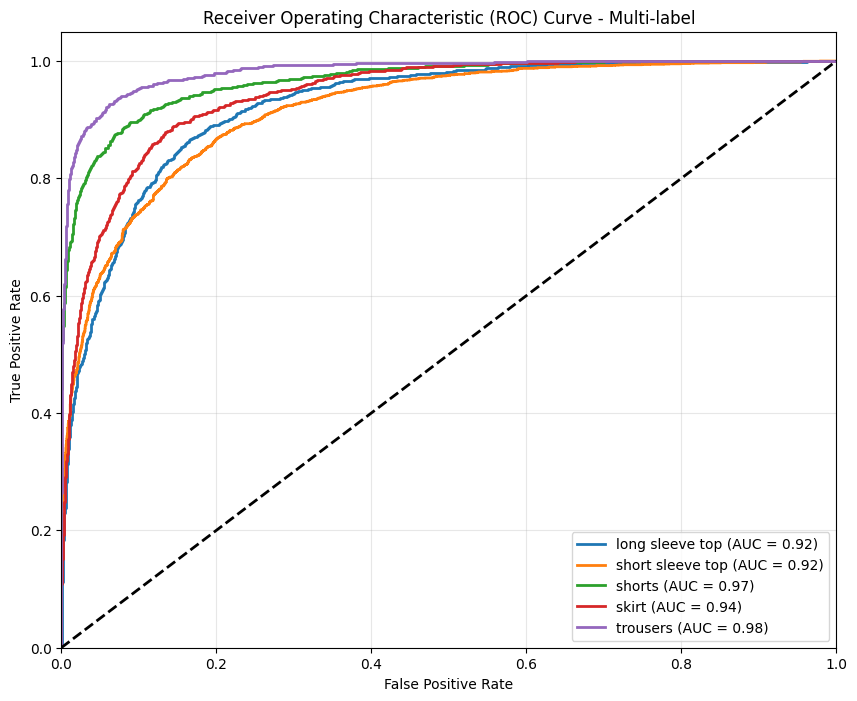

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multilabel_roc(all_labels, all_probs, class_names):
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-label')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Generate the plot using labels and probabilities from the latest model evaluation
plot_multilabel_roc(all_labels, all_probs, mlb.classes_)